# CS-430 Group Project: SLCM Data Analysis
## Part One: Exploratory Data Analysis (EDA)
---
### Project Structure
* **Task 0:** Data Provenance & Structure
* **Task 1:** Mapping Data to Partner Plan (Triage & Limitations)
* **Task 2:** The Five Questions (Exploration, Cleaning, Analysis)
* **Phase 3:** Presentation Outline & Advanced Optimizations

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Importing Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
from google.colab import drive
#File upload
intake = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/GroupProject/cleaned_intakes_masked.csv")
house = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/GroupProject/household_members_long_v2.csv")
print("Files loaded successfully!")
pd.set_option('display.max_columns', None)

Files loaded successfully!


## Task 0: Data Provenance

* **What the NEIG-##### ticket represents:** It represents a specific, unique instance or case of a neighbor seeking assistance, rather than a rolling file for the person.
* **Why ticket numbers are not sequential:** Ticket numbers (Issue IDs) increment globally across the entire SLCM system as time passes. Because SLCM serves many families simultaneously, other families submit tickets in between a single family's repeated visits.
* **Identifying new intakes vs. sub-tickets:** A new intake or unrelated problem is marked as 'New Profile' in the `Issue Type` column. Sub-tickets or continuations are marked with specific care paths (e.g., 'Rent Assistance Care Path').

In [ ]:
# Data Provenance
intake['Created_DT'] = pd.to_datetime(intake['Created'], errors='coerce')
cols_to_view = ['PID', 'Created_DT', 'Issue key', 'Issue id', 'Issue Type']

print("Tickets for PID 'P0101' showing non-sequential numbering due to time gaps:")
display(intake[intake['PID'] == 'P0101'][cols_to_view].sort_values('Created_DT'))

Tickets for PID 'P0101' showing non-sequential numbering due to time gaps:


/tmp/ipykernel_940/1016970889.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  intake['Created_DT'] = pd.to_datetime(intake['Created'], errors='coerce')


,PID,Created_DT,Issue key,Issue id,Issue Type
500,P0101,2026-03-09 11:35:00,NEIG-12683,44952,New Profile
482,P0101,2026-03-20 08:38:00,NEIG-13006,46817,Rent Assistance Care Path
424,P0101,2026-04-14 10:34:00,NEIG-13824,51352,New Profile
404,P0101,2026-04-17 13:05:00,NEIG-14015,52081,Rent Assistance Care Path
354,P0101,2026-05-07 14:28:00,NEIG-14662,55140,New Profile
172,P0101,2026-07-03 15:32:00,NEIG-16993,58324,New Profile


## Task 1: Map Data to the Partner Plan

### 1.1 Column Triage

**Keep (Case & Demographic Data):**
* `PID`, `Issue id`, `Issue Type`, `Created_DT`: Crucial for identifying unique families and chronological ticket tracking.
* `Custom field (Housing Status)`, `Custom field (Eviction Status)`: Core metrics for assessing housing crisis severity.
* `Custom field (Income Amount ($))`, `Custom field (Source of income)`: Needed for financial/income mismatch analysis.
* `Custom field (Employment Status)`: Required for employment vs. income analysis.
* `Custom field (Zip Code)`: For geographic analysis of need.
* `Age at Intake`, `Custom field (People in Household <18)`: Necessary for demographic profiling.

**Optional (Operational Context):**
* `Status`, `Resolution`: Useful for tracking ticket progress, but not needed for demographic EDA.
* `Has Email/Phone on File`: Not necessary for core outcome analysis.

**Drop (System Metadata):**
* `Reporter`, `Creator`, `Watchers`, `Parent key`, `Custom field (Rank)`: Internal Jira routing, sorting, and notification fields that are  irrelevant to the neighbor's living situation.

### 1.1 Column Triage Table

| Column Name | Classification | Reason |
| :--- | :--- | :--- |
| **PID** | Keep | Crucial for identifying unique individuals/families across multiple tickets. |
| **Issue key** | Keep | Secondary system identifier linked chronologically to the case. |
| **Issue id** | Keep | The primary unique identifier for each specific ticket. |
| **Issue Type** | Keep | Distinguishes between new intakes and specific follow-up care paths. |
| **Created** | Keep | Essential for chronological sorting and temporal analysis. |
| **Updated** | Keep | Shows the last time the ticket was modified. |
| **Resolved** | Keep | Indicates when the crisis intervention was completed. |
| **Custom field (Intake Date)** | Keep | The actual date the neighbor was processed. |
| **Custom field (Court Date)** | Keep | Highly relevant for measuring imminent eviction urgency. |
| **Custom field (Eviction Reason)** | Keep | Provides context on why the housing crisis is occurring. |
| **Custom field (Eviction Status)** | Keep | Directly measures immediate eviction risk for the partner plan quadrants. |
| **Custom field (Housing Status)** | Keep | Core metric for assessing baseline housing stability. |
| **Custom field (Household repairs required?)** | Keep | Indicates severe housing condition issues. |
| **Custom field (Loss of Income Causation)** | Keep | Core variable for understanding the root cause of financial hardship. |
| **Custom field (Loss of Income Causation).1-3** | Keep | Captures secondary/tertiary reasons for income loss. |
| **Custom field (Main reason stopped paying rent)** | Keep | Directly links to the eviction risk analysis. |
| **Custom field (Monthly Rent ())** | Keep | Needed to calculate cost-of-living vs. income mismatch. |
| **Custom field (Past Due Rent ())** | Keep | Quantifies the depth of the immediate financial crisis. |
| **Custom field (Rent-to-Income %)** | Keep | Highly predictive feature for housing instability. |
| **Custom field (Utility Past Due)** | Keep | Indicates secondary financial crises alongside housing. |
| **Custom field (Section 8 or Housing Voucher)** | Keep | Contextualizes whether they receive government housing aid. |
| **Custom field (Employment Status)** | Keep | Required to answer the employment vs. income question. |
| **Custom field (Income Amount ($))** | Keep | Required to answer the employment vs. income question. |
| **Custom field (Source of income)** | Keep | Identifies reliance on wages vs. government benefits. |
| **Custom field (Source of income).1** | Keep | Secondary income source tracking. |
| **# Additional Household Members** | Keep | Essential for understanding total household size. |
| **Custom field (People in Household 17 and Under)** | Keep | Identifies the number of children in the 0-5 target population. |
| **Custom field (People in Household 18+)** | Keep | Identifies adult dependents or multi-generational households. |
| **Custom field (People in Household 65+)** | Keep | Identifies elderly dependents adding financial strain. |
| **Custom field (Household Identities)** | Keep | Captures specific vulnerable population identifiers. |
| **Custom field (Household Identities).1** | Keep | Secondary population identifiers. |
| **Custom field (Goals)** | Keep | Maps to what the neighbor actually hopes to achieve with SLCM. |
| **Custom field (Goals).1-3** | Keep | Secondary goals for the neighbor. |
| **Custom field (Rent Intake Form Goals)** | Keep | Specific targeted outcomes for the rent assistance program. |
| **Custom field (Rent Intake Form Goals).1-3** | Keep | Secondary rent assistance goals. |
| **Age at Intake** | Keep | Essential demographic variable. |
| **Custom field (Gender)** | Keep | Essential demographic variable. |
| **Custom field (Race/Ethnicity)** | Keep | Essential demographic variable. |
| **Custom field (Primary Language Spoken in Home)** | Keep | Demographic variable indicating potential resource access barriers. |
| **Custom field (Zip Code)** | Keep | Required by the prompt to analyze geographic housing crises. |
| **Custom field (Community Ministry)** | Keep | Identifies if the case was shared or routed from another agency. |
| **Status** | Optional | Useful for tracking resolution but not strict demographic data. |
| **Resolution** | Optional | Shows ticket outcome, but redundant with 'Resolved' date. |
| **Status Category** | Optional | Broad Jira category for the workflow state. |
| **Labels.1-6** | Optional | Internal tags (e.g., SNAP, Medicaid) that are messy but potentially useful. |
| **Custom field (Insurance Provider for Family)** | Optional | Good for operational context but not core to housing/income. |
| **Custom field (Primary Insurance)** | Optional | Redundant with Insurance Provider field. |
| **Has Email on File** | Optional | Operational contact info, irrelevant to EDA outcome. |
| **Has Phone on File** | Optional | Operational contact info, irrelevant to EDA outcome. |
| **Has LG&E / Water Account on File** | Optional | Will be used in Phase 2 for utility data, optional for Phase 1. |
| **Custom field (Other professionals helping)** | Optional | Contextual but not highly quantifiable. |
| **Custom field (City / State)** | Optional | Almost entirely Louisville/KY, lacks variance compared to Zip Code. |
| **PID Match Basis** | Optional | Explains how the PID was generated, useful for data quality notes. |
| **Custom field (Preferred method of contact)** | Optional | Operational info only. |
| **Custom field (Response Method)** | Optional | Shows how staff replied, not what the client is experiencing. |
| **Comment (and .1, .2)** | Optional | Free text; hard to analyze in standard EDA without NLP. |
| **Reporter / Reporter Id** | Drop | Jira system data; tracks which staff member logged the ticket. |
| **Creator / Creator Id** | Drop | Jira system data; tracks staff who created the record. |
| **Watchers / Watchers Id** | Drop | Jira system data; tracks staff observing the ticket. |
| **Summary** | Drop | Auto-generated title for the Jira ticket. |
| **Custom field (Rank)** | Drop | Jira board sorting metadata. |
| **Custom field ([CHART] Date of First Response)** | Drop | Staff performance metric, not neighbor case data. |
| **Custom field ([CHART] Time in Status)** | Drop | Staff SLA metric, not neighbor case data. |
| **Status Category Changed** | Drop | System timestamp for workflow movement. |
| **Parent / Parent key / Parent summary** | Drop | Jira system linking metadata. |
| **Custom field (Landlord Name)** | Drop | Removed to protect privacy and prevent re-identification. |
| **Custom field (Current Employer)** | Drop | Too varied/text-heavy; employment status is sufficient. |
| **Custom field (Other Professionals Detail)** | Drop | Free text field that is messy and highly unstandardized. |
| **Custom field (Pronoun)** | Drop | Usually highly sparse or redundant with Gender. |

In [ ]:
# 1.2: Figures 1 & 2 Data Calculations

# --- FIGURE 1 LOGIC ---
# Assuming 'New Profile' represents the Reconnect stage
reconnect_df = intake[intake['Issue Type'] == 'New Profile']

# Define "Eviction Risk" as currently being evicted, unhoused or unknown
urgent_mask = (reconnect_df['Custom field (Eviction Status)'] == 'Currently being evicted') | (reconnect_df['Custom field (Housing Status)'] == 'Unhoused') | (reconnect_df['Custom field (Eviction Status)'] == 'Unknown')


fig1_eviction_risk = reconnect_df[urgent_mask].shape[0]
fig1_housing_stable = reconnect_df[~urgent_mask].shape[0]

print("--- FIGURE 1 RESULTS ---")
print(f"Total Reconnect Tickets: {len(reconnect_df)}")
print(f"Housing Stable: {fig1_housing_stable}")
print(f"Eviction Risk: {fig1_eviction_risk}")

# --- FIGURE 2 LOGIC ---

# Map Frequency (Episodic = 1, Chronic = 2+)
ticket_counts = intake['PID'].value_counts()
intake['Frequency'] = intake['PID'].map(lambda x: 'Episodic' if ticket_counts[x] == 1 else 'Chronic')

# Map Urgency
intake['Urgency'] = np.where(
    (intake['Custom field (Eviction Status)'] == 'Currently being evicted') |
    (intake['Custom field (Housing Status)'] == 'Unhoused'),
    'Urgent', 'Less Urgent'
)

# Displaying the four quadrants
fig2_matrix = pd.crosstab(intake['Frequency'], intake['Urgency'])
print("\n--- FIGURE 2 RESULTS (Quadrants) ---")
display(fig2_matrix)

--- FIGURE 1 RESULTS ---
Total Reconnect Tickets: 378
Housing Stable: 212
Eviction Risk: 166

--- FIGURE 2 RESULTS (Quadrants) ---


Urgency,Less Urgent,Urgent
Frequency,,
Chronic,319,31
Episodic,200,89


### 1.3 Partner Plan Gaps
The data heavily supports the **"Reconnect"** phase (identifying immediate crises like eviction and job loss).

**What is missing:** The data does NOT currently support the "Rethink" or "Rebuild" stages. There are no fields that track long-term outcomes (e.g., housing status 6 months *after* the intervention) or whether a neighbor successfully increased their savings.
**Proposal:** SLCM should start collecting 3-month and 6-month "Follow-up Status" fields to measure true housing retention, rather than just immediate crisis intake.

## Task 2: Explore, Clean, and Answer

### 2.1 File Summaries (Row/Column Counts & Data Types)


In [ ]:
# --- Summarize the Intakes Dataset ---
print("--- INTAKES DATASET ---")
print(f"Row/Column Count: {intake.shape[0]} rows, {intake.shape[1]} columns")
print("\nData Types Summary:")
display(intake.dtypes.value_counts().to_frame('Count'))

# Data and full column info
display(intake.head(3))
intake.info()

--- INTAKES DATASET ---
Row/Column Count: 639 rows, 96 columns

Data Types Summary:


,Count
object,87
float64,6
int64,2
datetime64[ns],1


,PID,PID Match Basis,Summary,Issue key,Issue id,Issue Type,Status,Resolution,Reporter,Reporter Id,Creator,Creator Id,Created,Updated,Resolved,Labels.1,Labels.2,Labels.3,Labels.4,Labels.5,Labels.6,Watchers,Watchers.1,Watchers Id,Watchers Id.1,# Additional Household Members,Custom field (City),Custom field (Community Ministry),Custom field (Court Date),Custom field (Current Employer),Age at Intake,Custom field (Employment Status),Custom field (Eviction Reason),Custom field (Eviction Status),Custom field (Gender),Custom field (Goals),Custom field (Goals).1,Custom field (Goals).2,Custom field (Goals).3,Custom field (Household Identities),Custom field (Household Identities).1,Custom field (Household repairs required?),Custom field (Housing Status),Custom field (Income Amount ($)),Custom field (Insurance Provider for Family),Custom field (Intake Date),Has LG&E Account on File,Custom field (Landlord Name),Custom field (Loss of Income Causation),Custom field (Loss of Income Causation).1,Custom field (Loss of Income Causation).2,Custom field (Loss of Income Causation).3,Custom field (Main reason Neighbor stopped paying rent),Custom field (Monthly Rent ($)),Has Email on File,Has Phone on File,Custom field (Other Professionals Detail),Custom field (Other professionals helping with goals?),Custom field (Past Due Rent ($)),Custom field (People in Household 17 and Under),Custom field (People in Household 18+),Custom field (People in Household 65+),Custom field (Preferred method of contact),Custom field (Preferred method of contact).1,Custom field (Primary Insurance),Custom field (Primary Language Spoken in Home),Custom field (Pronoun),Custom field (Race/Ethnicity),Custom field (Rank),Custom field (Rent Intake Form Goals),Custom field (Rent Intake Form Goals).1,Custom field (Rent Intake Form Goals).2,Custom field (Rent Intake Form Goals).3,Custom field (Rent-to-Income %),Custom field (Response Method),Custom field (Response Method).1,Custom field (Section 8 or Housing Voucher),Custom field (Source of income),Custom field (Source of income).1,Custom field (State),Custom field (Utility Past Due),Has Water Account on File,Custom field (Zip Code),Custom field ([CHART] Date of First Response),Custom field ([CHART] Time in Status),Comment,Comment.1,Comment.2,Parent,Parent key,Parent summary,Status Category,Status Category Changed,Created_DT,Frequency,Urgency
0,P0289,Name + DOB,Person P0289,NEIG-19349,60769,New Profile,Initial Contact,NaN,Johanna South,712020:3b2c2185-c76f-4d90-ad8c-9e260c73c318,Johanna South,712020:3b2c2185-c76f-4d90-ad8c-9e260c73c318,12/Aug/26 11:12 AM,12/Aug/26 1:37 PM,NaN,Passport,SNAP,WLCM,Workforce-Unemployed,Young-adult,NaN,Johanna South,NaN,712020:3b2c2185-c76f-4d90-ad8c-9e260c73c318,NaN,2,Louisville,WLCM,NaN,NaN,24.0,Unemployed but want to find work,NaN,Not being evicted,Woman,Financial Stability Care Path,NaN,NaN,NaN,Pregnant or recently postpartum,NaN,No,Other,0.0,Passport by Molina,12/Aug/26 12:00 AM,No,Ms Cathy,Childbirth,NaN,NaN,NaN,NaN,NaN,Yes,Yes,NaN,No,NaN,2,0,No,Call,Text,Medicaid,English,she/her,Black of African American,0|i03a6v:,NaN,NaN,NaN,NaN,NaN,An email with available resources and next steps,A phone call to further explain where you woul...,No,Food benefits - TANF/SNAP,No income,KY,NaN,No,40210,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,In Progress,12/Aug/26 1:37 PM,2026-08-12 11:12:00,Episodic,Less Urgent
1,P0352,Name + DOB,Person P0352,NEIG-19336,60756,New Profile,Second Contact,NaN,Johanna South,712020:3b2c2185-c76f-4d90-ad8c-9e260c73c318,Johanna South,712020:3b2c2185-c76f-4d90-ad8c-9e260c73c318,12/Aug/26 10:25 AM,12/Aug/26 4:18 PM,NaN,LGBTQIA+,SLCM,Workforce-Unemployed,NaN,NaN,NaN,James Bryant,Johanna South,712020:7919ac37-40c1-4b22-a858-9d188e7777ec,712020:3b2c2185-c76f-4d90-ad8c-9e260c73c318,0,Louisville,SLCM,NaN,NaN,42.0,Unemployed but want to find work,NaN,Unknown,Woman,Behavioral Health Care Path,Financial Stability Care Path,Food Care Path,Healthcare Care Path,LGBTQIA+,Person with a physical or mental disab

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639 entries, 0 to 638
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype         
---  ------                                                   --------------  -----         
 0   PID                                                      639 non-null    object        
 1   PID Match Basis                                          639 non-null    object        
 2   Summary                                                  639 non-null    object        
 3   Issue key                                                639 non-null    object        
 4   Issue id                                                 639 non-null    int64         
 5   Issue Type                                               639 non-null    object        
 6   Status                                                   639 non-null    object        
 7   Resolution                                           

In [ ]:
# --- Summarize the Household Members Dataset ---
print("--- HOUSEHOLD MEMBERS DATASET ---")
print(f"Row/Column Count: {house.shape[0]} rows, {house.shape[1]} columns")
print("\nData Types Summary:")
display(house.dtypes.value_counts().to_frame('Count'))

# Data and full column info
display(house.head(3))
house.info()

--- HOUSEHOLD MEMBERS DATASET ---
Row/Column Count: 993 rows, 8 columns

Data Types Summary:


,Count
object,6
int64,1
float64,1


,PID,Member ID,Issue key,Member #,Age,Gender,Race/Ethnicity,Relationship
0,P0289,P0289-M1,NEIG-19349,1,4.0,Female,African-American,Daughter
1,P0289,P0289-M2,NEIG-19349,2,0.0,Male,African-American,Son
2,P0308,P0308-M1,NEIG-19324,1,34.0,Female,black/white,Fiancé


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 993 entries, 0 to 992
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PID             993 non-null    object 
 1   Member ID       993 non-null    object 
 2   Issue key       993 non-null    object 
 3   Member #        993 non-null    int64  
 4   Age             900 non-null    float64
 5   Gender          648 non-null    object 
 6   Race/Ethnicity  388 non-null    object 
 7   Relationship    632 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 62.2+ KB


### 2.2: Data Quality & Cleaning
1. **Inconsistent Income Formatting:** The Income column contains text/errors instead of pure floats. Handled by coercing to numeric (`pd.to_numeric`).
2. **Missing Employment Status:** Missing in ~33% of tickets. Handled by filling with 'Unknown' so we don't lose valuable housing data for those rows.

In [ ]:
# Apply Cleaning Steps
intake['Income_Amount'] = pd.to_numeric(intake['Custom field (Income Amount ($))'], errors='coerce')
intake['Employment_Status'] = intake['Custom field (Employment Status)'].fillna('Unknown')

### Variable Exploration

*Goal: Explore key variables kept from the triage, focusing on unusual distributions, outliers, or missingness before answering specific questions.*

**Exploration Observations:**

**Income Amount:** Highly right-skewed. The vast majority of neighbors report zero dollars or very low income.But, there are extreme outliers reporting over $10,000/month, which could be data entry errors e.g., entering annual income instead of monthly.

**Age at Intake:** Mostly normally distributed around the late 20s to 30s, representing parents of the 0-5 population, though there are a few elderly outliers (grandparents acting as primary guardians).

**Missingness:** Aside from the Employment Status, variables like Custom field (Eviction Reason) and Custom field (Monthly Rent ($)) have massive amounts of missing data, likely because they only apply to specific 'Rent Assistance' care paths and are left blank for general intakes.

In [ ]:
# --- General Variable Exploration ---
#Checking age and income distributions
display(intake[['Age at Intake', 'Income_Amount']].describe())

,Age at Intake,Income_Amount
count,426.000000,426.000000
mean,30.899061,1681.958920
std,8.018898,5149.032095
min,-1.000000,0.000000
25%,26.000000,0.000000
50%,30.000000,907.000000
75%,35.000000,2000.000000
max,71.000000,75000.000000


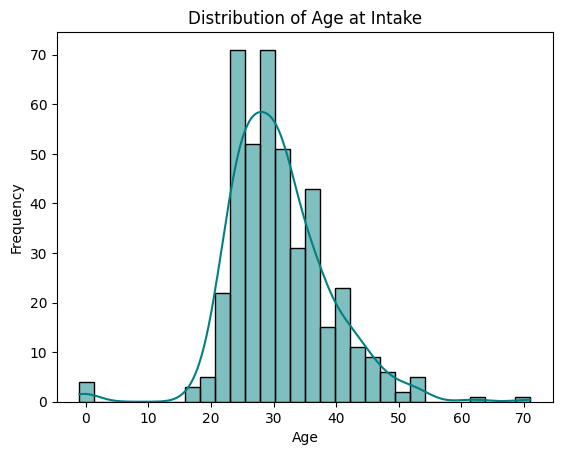

In [ ]:
#fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of Age at Intake
sns.histplot(data=intake, x='Age at Intake', bins=30, kde=True, color='teal')
plt.title('Distribution of Age at Intake', fontsize=12)
plt.xlabel('Age')
plt.ylabel('Frequency')

#plt.tight_layout()
plt.show()

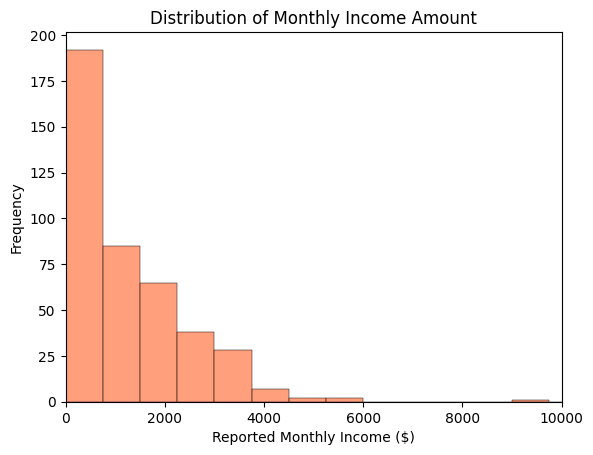

In [ ]:
# Plot 2: Distribution of Income (Showing skewness and outliers)

sns.histplot(data=intake['Income_Amount'].dropna(), bins=100, color='coral')
plt.title('Distribution of Monthly Income Amount', fontsize=12)
plt.xlabel('Reported Monthly Income ($)')
plt.ylabel('Frequency')
plt.xlim(0, 10000)

plt.show()
#This plot excludes outliers more than $10,000

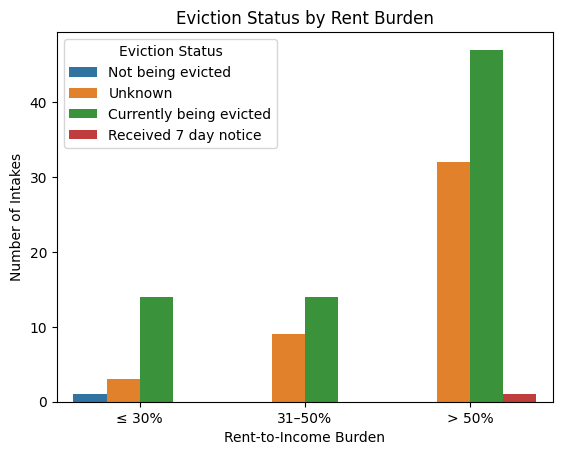

In [ ]:
# Plot 3: Comparing eviction status with proportion of income paying rent
#Categorizing rent_to_income by percent
intake['Rent_to_Income'] = np.where(
    intake['Income_Amount'] > 0,
    (
        intake['Custom field (Monthly Rent ($))'] /
        intake['Income_Amount']
    ) * 100, np.nan)

intake['Rent_Burden'] = pd.cut(
    intake['Rent_to_Income'],
    bins = [-float('inf'), 30, 50, float('inf')],
    labels = ['≤ 30%', '31–50%', '> 50%'])

sns.countplot(
    x = intake['Rent_Burden'],
    hue = intake['Custom field (Eviction Status)'])

plt.title('Eviction Status by Rent Burden', fontsize = 12)
plt.xlabel('Rent-to-Income Burden')
plt.ylabel('Number of Intakes')

plt.legend(
    title = 'Eviction Status',
    loc = 'upper left'
)

plt.show()

#This visual shows us that over half of the neighbors currently being evicted
#spend fifty percent or more of their monthly income on rent.

In [ ]:
#We found that neighbors that are not facing eviction do not have reported
#monthly rent, therefore we cannot compare the ratio of rent to income
#for those facing eviciton to those who are not.

intake[
    intake['Custom field (Eviction Status)'] == 'Not being evicted'
][[
    'Income_Amount',
    'Custom field (Monthly Rent ($))',
    'Rent_to_Income',
    'Rent_Burden'
]].head(15)

,Income_Amount,Custom field (Monthly Rent ($)),Rent_to_Income,Rent_Burden
0,0.0,NaN,NaN,NaN
2,3000.0,NaN,NaN,NaN
3,998.0,NaN,NaN,NaN
8,994.0,NaN,NaN,NaN
9,0.0,NaN,NaN,NaN
11,1100.0,NaN,NaN,NaN
13,1000.0,NaN,NaN,NaN
14,0.0,NaN,NaN,NaN
15,3360.0,NaN,NaN,NaN
16,0.0,NaN,NaN,NaN


## Task 3: Five Questions

### Q1: Housing Crisis Severity
**Answer:** A significant portion of neighbors face active eviction risks, and this is heavily concentrated in specific zip codes.

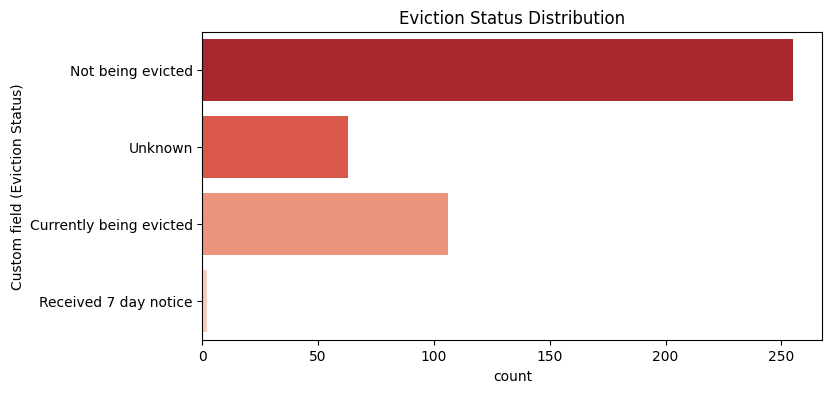

Top 5 Zip Codes with Active Evictions:


,count
Custom field (Zip Code),
40214,20
40215,9
40216,8
40212,7
40272,6
40219,5
40210,5
40218,4
40206,4


In [ ]:
# Q1 Code
plt.figure(figsize=(8, 4))
sns.countplot(data=intake, y='Custom field (Eviction Status)', palette='Reds_r', hue='Custom field (Eviction Status)', legend=False)
plt.title("Eviction Status Distribution")
plt.show()

evictions_only = intake[intake['Custom field (Eviction Status)'] == 'Currently being evicted']
print("Top 5 Zip Codes with Active Evictions:")
display(evictions_only['Custom field (Zip Code)'].value_counts().head(10))

### Q2: Employment vs. Income Mismatch
**Answer:** Employment alone does not prevent financial hardship. Fully employed individuals have a median income of just $2,293.50/month, leaving them vulnerable to crises.

/tmp/ipykernel_940/2955292623.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(wrapped_labels)


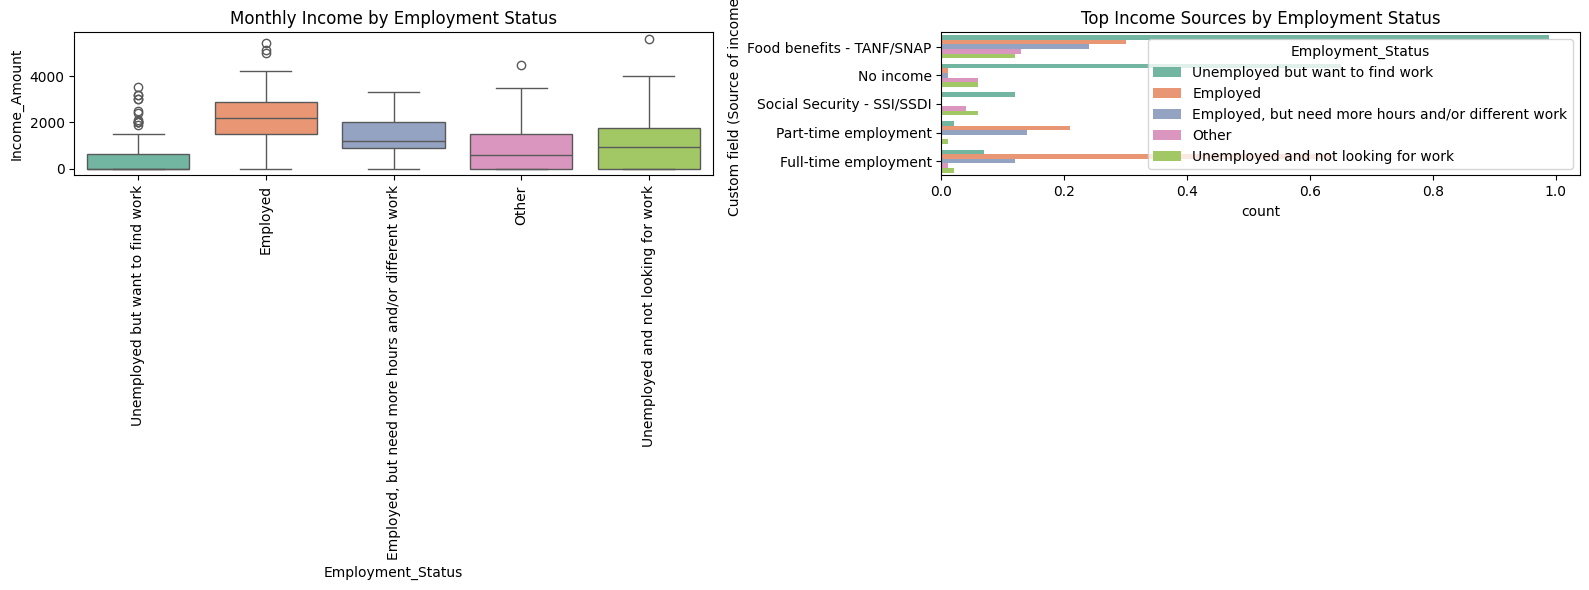

,Median Income ($)
Employment_Status,
Employed,2293.5
"Employed, but need more hours and/or different work",1200.0
Other,600.0
Unemployed and not looking for work,924.0
Unemployed but want to find work,0.0
Unknown,NaN


In [ ]:
# Q2 Code
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=intake[intake['Income_Amount'] < 8000], x='Employment_Status', y='Income_Amount', ax=axes[0], palette='Set2', hue='Employment_Status', legend=False)
axes[0].set_title('Monthly Income by Employment Status')
axes[0].tick_params(axis='x', rotation=90)

top_sources = intake['Custom field (Source of income)'].value_counts().nlargest(5).index
sns.countplot(data=intake[intake['Custom field (Source of income)'].isin(top_sources)], y='Custom field (Source of income)', hue='Employment_Status', ax=axes[1], palette='Set2')
axes[1].set_title('Top Income Sources by Employment Status')

plt.tight_layout()
plt.show()

display(intake.groupby('Employment_Status')['Income_Amount'].median().to_frame('Median Income ($)'))

### Q3: Household Composition
**Answer:** The typical household seeking assistance includes multiple dependents. There is an average of 2.66 additional members per family, and 77.3% of these additional members are children under 18 (median age 6).

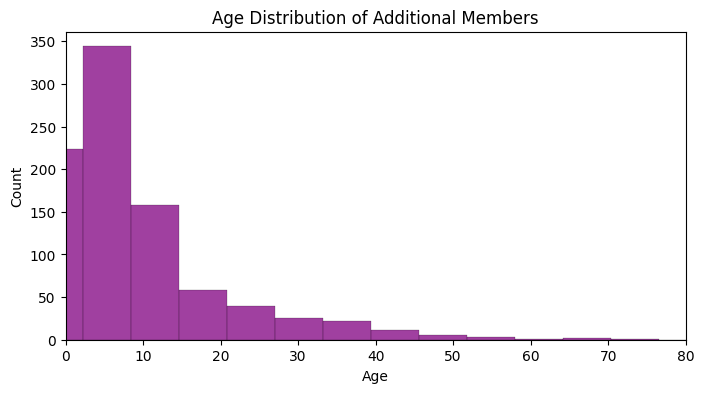

Average children (<18) per family: 2.39
Median age of additional members: 6.0 years


In [ ]:
# Q3 Code
house['Is_Child'] = house['Age'] < 18
children_per_hh = house[house['Is_Child']].groupby('PID')['Member ID'].count()

plt.figure(figsize=(8, 4))
sns.histplot(data=house, x='Age', bins=300, color='purple')
plt.title('Age Distribution of Additional Members')
plt.xlim(0, 80)

plt.show()

print(f"Average children (<18) per family: {children_per_hh.mean():.2f}")
print(f"Median age of additional members: {house['Age'].median():.1f} years")

### Q4: Repeat Contact
**Answer:** 150 unique individuals submitted multiple tickets. For the vast majority, their immediate crisis state (Eviction/Housing status) did not change between their first and most recent ticket, indicating prolonged instability.

In [ ]:
# Q4 Code
ticket_counts = intake['PID'].value_counts()
repeat_pids = ticket_counts[ticket_counts > 1].index
#Comparing first and last eviction status for each PID
repeats_df = intake[intake['PID'].isin(repeat_pids)].sort_values(by=['PID', 'Created_DT'])
first_tickets = repeats_df.groupby('PID').first()[['Custom field (Housing Status)', 'Custom field (Eviction Status)']]
last_tickets = repeats_df.groupby('PID').last()[['Custom field (Housing Status)', 'Custom field (Eviction Status)']]

comparison_df = first_tickets.join(last_tickets, lsuffix='_First', rsuffix='_Last')
eviction_changed = (comparison_df['Custom field (Eviction Status)_First'] != comparison_df['Custom field (Eviction Status)_Last']).sum()

print(f"Out of {len(repeat_pids)} repeat contacts:")
print(f"Eviction Status changed for only {eviction_changed} people between their first and last ticket.")

Out of 150 repeat contacts:
Eviction Status changed for only 8 people between their first and last ticket.


### Q5: Data Quality

In [ ]:
intake['Employment_Status'].value_counts()

,count
Employment_Status,
Unknown,213
Unemployed but want to find work,195
Employed,118
"Employed, but need more hours and/or different work",57
Other,29
Unemployed and not looking for work,27


One issue with the quality of this data is the abundance of null and missing values. One example of this is in the Employment_status column, where we filled over thirty percent of the values as 'Unknown' due to incomplete data. We may consider undersampling as a way to manage the missing data when implementing ML modeling.

In [ ]:
intake['Resolution'].value_counts()

,count
Resolution,
Done,56
Won't Do,17


The second quality issue we found was the lack of robust follow-up to know if the aid administered for a given ticket was effective in helping that person long term. We can assume that immediate aid helps a neighbor in the short term, but we feel that data collected on long term status would help better understand whether unstable status is maintained or transitioned out of. The way we managed this problem is looking at if a neighbor's eviction status changed ovre multiple tickets.

## Conclusion: What did we get to know?

**What surprised us:** We were surprised by the sheer number of neighbors who are fully employed yet still facing immediate housing crises like active eviction. The data clearly shows that having a job is not a guaranteed shield against severe financial hardship when the median income for the fully employed is roughly $2,293/month.

**What we now believe:** Before analyzing this data, one might assume that the majority of those seeking emergency assistance are single or unemployed. We now believe that SLCM's primary demographic consists heavily of active, working families with multiple dependents (averaging 2 children per household). *The crisis is largely a wage-to-cost-of-living mismatch rather than a strict lack of employment.*

**One unanswered question:** *Does the assistance provided actually lead to long-term housing stability?* Because the data is heavily focused on immediate intake and crisis resolution, we lack follow-up metrics to see if these families are securely housed 6 or 12 months after their ticket is closed.